In [1]:
import os
import subprocess
import json
from pathlib import Path
import numpy as np
import pandas as pd
import earthkit.data
import matplotlib.pyplot as plt
import logging, warnings
import xarray as xr
import sys
from netCDF4 import Dataset
import netCDF4 as nc
import cartopy.crs as ccrs
from eccodes import (
    codes_grib_new_from_file,
    codes_get,
    codes_get_array,
    codes_get_values,
    codes_release,
)
import gc

base_dir = ('C:/Users/Administrator/Documents/SnowPI_Hackathon/')

In [2]:
# Code adapted from Ulrike
def mosaic_track_select(time_start,time_end,file_dir):
    PERIOD = slice(time_start,time_end)

    obs = xr.open_dataset(file_dir).sel(time=PERIOD)
    obs_t2m = obs.temp_2m.to_series()  # deg C
    obs_wspd_10m = obs.wspd_vec_mean_10m.to_series()  # deg C
    mosaic_track = pd.DataFrame({
        "lat": obs.lat.to_series(),
        "lon": obs.lon.to_series()})
    
    # Temp
    print(f"{obs_t2m.notna().sum()} of {len(obs_t2m)} hourly obs available, "
          f"{obs_t2m.index[0]} .. {obs_t2m.index[-1]}")
    print(obs_t2m.describe().round(2))
    # Wind speed
    print(f"{obs_wspd_10m.notna().sum()} of {len(obs_wspd_10m)} hourly obs available, "
          f"{obs_wspd_10m.index[0]} .. {obs_wspd_10m.index[-1]}")
    print(obs_wspd_10m.describe().round(2))

    return(mosaic_track,obs_t2m,obs_wspd_10m)

def mosaic_latlon_select(mosaic_track,buffer_km):
    print(f"mosaic min lon {mosaic_track['lon'].min()}")
    print(f"mosaic max lon {mosaic_track['lon'].max()}")
    
    print(f"mosaic min lat {mosaic_track['lat'].min()}")
    print(f"mosaic max lat {mosaic_track['lat'].max()}")
    
    track_min_lat = mosaic_track["lat"].min()
    track_max_lat = mosaic_track["lat"].max()
    track_min_lon = mosaic_track["lon"].min()
    track_max_lon = mosaic_track["lon"].max()
    
    # Approximate latitude distance: 1 degree latitude ≈ 111.3 km
    lat_buffer = buffer_km / 111.32
    
    # Longitude distance depends on latitude.
    # Use the lowest latitude to give a conservative buffer.
    mean_lat = track_min_lat
    lon_buffer = buffer_km / (111.32 * np.cos(np.deg2rad(mean_lat)))
    
    min_lat = track_min_lat - lat_buffer
    max_lat = track_max_lat + lat_buffer
    
    min_lon = track_min_lon - lon_buffer
    max_lon = track_max_lon + lon_buffer
    
    print("Crop bounds:")
    print(f"lat: {min_lat:.3f} to {max_lat:.3f}")
    print(f"lon: {min_lon:.3f} to {max_lon:.3f}")

    return(min_lat,max_lat,min_lon,max_lon)


# Slice CARRA2 Data

## Process MOSAiC track for time period

This can be upgraded to a loop but I used manual monthly inputs to investigate the results

In [3]:
time_start = '2019-12-01'
time_end = '2019-12-31'

# Slice the MOSAIC track for the given timeframe and create a lat/lon buffer (default is 50)
mosaic_track, obs_t2m, obs_wspd_10m = mosaic_track_select(time_start,time_end,f"{base_dir}/mosaic-examples/MOSAiC_obs_combined_1h_v2.nc")
min_lat,max_lat,min_lon,max_lon = mosaic_latlon_select(mosaic_track,50)



744 of 744 hourly obs available, 2019-12-01 00:00:00 .. 2019-12-31 23:00:00
count    744.00
mean     -24.50
std        4.91
min      -37.04
25%      -27.78
50%      -24.57
75%      -20.92
max      -14.53
Name: temp_2m, dtype: float64
744 of 744 hourly obs available, 2019-12-01 00:00:00 .. 2019-12-31 23:00:00
count    744.00
mean       5.22
std        3.19
min        0.27
25%        2.60
50%        4.75
75%        7.05
max       13.95
Name: wspd_vec_mean_10m, dtype: float64
mosaic min lon 112.39539
mosaic max lon 122.29425
mosaic min lat 85.92247
mosaic max lat 86.68885
Crop bounds:
lat: 85.473 to 87.138
lon: 106.079 to 128.611


## Process CARRA2 Data

In [4]:
grib_file = f"{base_dir}CARRA2/CARRA_201912_Analysis_Wspd_2mTemp_SIF.grib"
output_dir = f"{base_dir}CARRA2/MOSAiC_Subsets/Monthly/"

month_save = '201912'

# t2m + wspd10 combined - same native grid, confirmed above
params = {
    "file_dir": grib_file,
    "shortname_variable_map": {"2t": "t2m", "10si": "wspd10"},
    "time_start": time_start,
    "time_end": time_end,   # inclusive - a full week in one call
    "min_lat": min_lat, "max_lat": max_lat,
    "min_lon": min_lon, "max_lon": max_lon,
    "out_path": f"{output_dir}CARRA2_{month_save}_MOSAiC_t2m_wspd10.nc",
}

result = subprocess.run(
    [sys.executable, "extract_carra2_mosaic.py", json.dumps(params)],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("FAILED:\n", result.stderr)

[log] start: RSS=105.8 MB 
  2t: scanned 268, kept 268 in window
  10si: scanned 268, kept 268 in window
[log] after extraction: RSS=323.0 MB 
[log] after to_netcdf: RSS=329.7 MB 
Saved C:/Users/Administrator/Documents/SnowPI_Hackathon/CARRA2/MOSAiC_Subsets/Monthly/CARRA2_201912_MOSAiC_t2m_wspd10.nc



# Plotting

In [18]:
# Code from Ulrike
def nearest_index(lat0, lon0, lat2d, lon2d):
    """Index of the grid point closest to (lat0, lon0), great-circle distance."""
    la, lo = np.radians(lat2d), np.radians(lon2d)
    d = np.arccos(np.clip(
        np.sin(np.radians(lat0)) * np.sin(la)
        + np.cos(np.radians(lat0)) * np.cos(la) * np.cos(lo - np.radians(lon0)),
        -1, 1))
    return np.unravel_index(np.nanargmin(d), d.shape)

def nearest_mosaic_carra2(carra2,input_variable,mosaic_track,mosaic_obs):
    c_var = carra2[input_variable].load()              
    c_lat = carra2.latitude.values
    c_lon = (carra2.longitude.values + 180) % 360 - 180
    c_times = pd.DatetimeIndex(carra2.time.values)

    if not c_times.is_unique:
        print(
            f"WARNING: {input_variable} contains "
            f"{c_times.duplicated().sum()} duplicate timestamps."
        )
    
        keep = ~c_times.duplicated()
    
        c_var = c_var.isel(time=keep)
        c_times = c_times[keep]
    
        print(f"Removed {np.sum(~keep)} duplicate timestamps.")
    
    timen = "time"
    print(f"cropped grid: {c_lat.shape}, {c_times[0]} .. {c_times[-1]} ({len(c_times)} analyses)")

    pos = mosaic_track.reindex(c_times, method="nearest", tolerance=pd.Timedelta("1h"))

    vals, dists = [], []
    spatial_dims = [d for d in c_var.dims if d != timen]
    for i, t in enumerate(c_times):
        if np.isnan(pos["lat"].iloc[i]):
            vals.append(np.nan); dists.append(np.nan); continue
        iy, ix = nearest_index(pos["lat"].iloc[i], pos["lon"].iloc[i], c_lat, c_lon)
        vals.append(float(c_var.isel({timen: i, spatial_dims[0]: iy, spatial_dims[1]: ix})))
        dists.append(6371.0 * np.arccos(np.clip(
            np.sin(np.radians(pos['lat'].iloc[i])) * np.sin(np.radians(c_lat[iy, ix]))
            + np.cos(np.radians(pos['lat'].iloc[i])) * np.cos(np.radians(c_lat[iy, ix]))
            * np.cos(np.radians(c_lon[iy, ix] - pos['lon'].iloc[i])), -1, 1)))
    
    carra_var = pd.Series(vals, index=c_times, name="CARRA2")
    if carra_var.mean() > 150:          # K -> deg C if needed
        carra_var -= K0
    print(f"{carra_var.notna().sum()} CARRA2 values at the floe, "
          f"max distance to nearest grid point: {np.nanmax(dists):.2f} km")
    carra_var.describe().round(2)

    df = pd.DataFrame({"MOSAiC obs": mosaic_obs,
        "CARRA2": carra_var})
    common = df.dropna() 

    return(common)

## One File

In [21]:
K0 = 273.15
time_start = '2019-12-01'
time_end = '2019-12-31'
mosaic_track, obs_t2m, obs_wspd_10m = mosaic_track_select(time_start,time_end,f"{base_dir}/mosaic-examples/MOSAiC_obs_combined_1h_v2.nc")

carra2 = xr.open_dataset(f"C:/Users/Administrator/Documents/SnowPI_Hackathon/CARRA2/MOSAiC_Subsets/Monthly/CARRA2_201912_MOSAiC_t2m_wspd10.nc")
t2m_df = nearest_mosaic_carra2(carra2,'t2m',mosaic_track,obs_t2m)
wspd_df = nearest_mosaic_carra2(carra2,'wspd10',mosaic_track,obs_wspd_10m)


744 of 744 hourly obs available, 2019-12-01 00:00:00 .. 2019-12-31 23:00:00
count    744.00
mean     -24.50
std        4.91
min      -37.04
25%      -27.78
50%      -24.57
75%      -20.92
max      -14.53
Name: temp_2m, dtype: float64
744 of 744 hourly obs available, 2019-12-01 00:00:00 .. 2019-12-31 23:00:00
count    744.00
mean       5.22
std        3.19
min        0.27
25%        2.60
50%        4.75
75%        7.05
max       13.95
Name: wspd_vec_mean_10m, dtype: float64
Removed 20 duplicate timestamps.
cropped grid: (95, 93), 2019-12-01 00:00:00 .. 2019-12-31 21:00:00 (248 analyses)
248 CARRA2 values at the floe, max distance to nearest grid point: 1.58 km
Removed 20 duplicate timestamps.
cropped grid: (95, 93), 2019-12-01 00:00:00 .. 2019-12-31 21:00:00 (248 analyses)
248 CARRA2 values at the floe, max distance to nearest grid point: 1.58 km


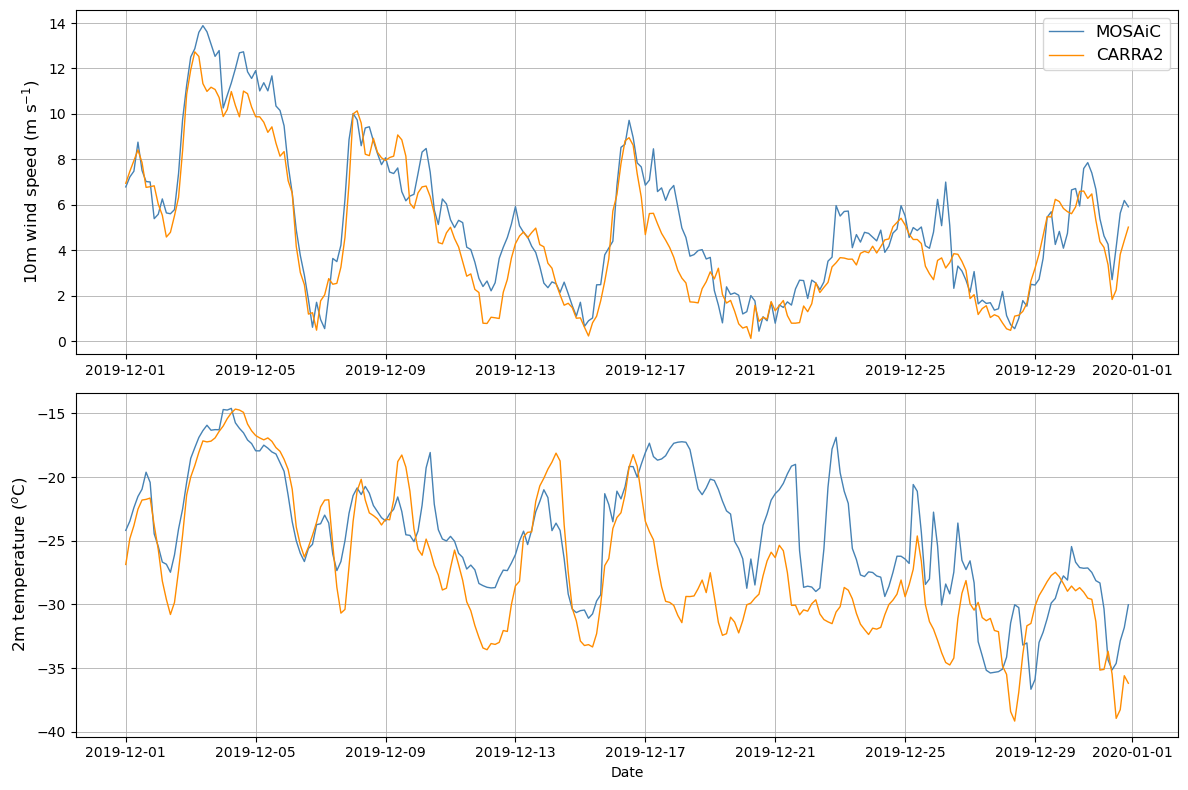

In [22]:
fig, ax = plt.subplots(2,1,figsize=(12, 8))
ax[0].plot(wspd_df['MOSAiC obs'], lw=1, color='steelblue',label='MOSAiC')
ax[0].plot(wspd_df['CARRA2'], lw=1, color='darkorange',label='CARRA2')
ax[0].set_ylabel('10m wind speed (m s$^{-1}$)',fontsize=12)

ax[1].plot(t2m_df['MOSAiC obs'], lw=1, color='steelblue')
ax[1].plot(t2m_df['CARRA2'], lw=1, color='darkorange')
ax[1].set_ylabel('2m temperature ($^{o}$C)',fontsize=12)

for i in range(0,2):
    ax[i].grid(linewidth = 0.6)

ax[1].set_xlabel('Date')
ax[0].legend(fontsize=12)
plt.tight_layout()
plt.show()

## All Months

In [32]:
months = ['201910','201911','201912','202001','202002',
          '202003','202004','202005','202006','202007','202008']

t2m_dfs, wspd_dfs = [],[]

K0 = 273.15
for month in months[:]:
    carra2 = xr.open_dataset(f"{base_dir}CARRA2/MOSAiC_Subsets/Monthly/CARRA2_{month}_MOSAiC_t2m_wspd10.nc")

    time_start = pd.to_datetime(month, format='%Y%m').strftime('%Y-%m-%d')
    time_end = (pd.to_datetime(month, format='%Y%m') + pd.offsets.MonthEnd(1)).strftime('%Y-%m-%d')
    mosaic_track, obs_t2m, obs_wspd_10m = mosaic_track_select(time_start,time_end,f"{base_dir}/mosaic-examples/MOSAiC_obs_combined_1h_v2.nc")

    t2m_df = nearest_mosaic_carra2(carra2,'t2m',mosaic_track,obs_t2m)
    wspd_df = nearest_mosaic_carra2(carra2,'wspd10',mosaic_track,obs_wspd_10m)

    t2m_df = t2m_df.reset_index()
    wspd_df = wspd_df.reset_index()

    t2m_dfs.append(t2m_df)
    wspd_dfs.append(wspd_df)

t2m_all = pd.concat(t2m_dfs, ignore_index=True)
wspd_all = pd.concat(wspd_dfs, ignore_index=True)

187 of 744 hourly obs available, 2019-10-01 00:00:00 .. 2019-10-31 23:00:00
count    187.00
mean     -19.68
std        4.15
min      -26.18
25%      -22.87
50%      -20.67
75%      -16.01
max      -11.40
Name: temp_2m, dtype: float64
187 of 744 hourly obs available, 2019-10-01 00:00:00 .. 2019-10-31 23:00:00
count    187.00
mean       5.59
std        1.27
min        2.93
25%        4.46
50%        5.54
75%        6.52
max        8.55
Name: wspd_vec_mean_10m, dtype: float64
cropped grid: (109, 110), 2019-10-01 00:00:00 .. 2019-10-31 21:00:00 (248 analyses)
248 CARRA2 values at the floe, max distance to nearest grid point: 1.73 km
cropped grid: (109, 110), 2019-10-01 00:00:00 .. 2019-10-31 21:00:00 (248 analyses)
248 CARRA2 values at the floe, max distance to nearest grid point: 1.73 km
644 of 720 hourly obs available, 2019-11-01 00:00:00 .. 2019-11-30 23:00:00
count    644.00
mean     -20.32
std        6.05
min      -31.89
25%      -24.53
50%      -20.63
75%      -16.53
max       -4.93


In [53]:
def hourly_timestamp(input_df):
    input_df['Datetime'] = pd.to_datetime(input_df['Date'])
    input_df_all = input_df.set_index('Datetime')
    full_time = pd.date_range(
        input_df_all.index.min(),
        input_df_all.index.max(),
        freq='3h')
    input_all_full = input_df_all.reindex(full_time)
    input_all_full.index.name = 'Datetime'
    input_all_full = input_all_full.reset_index()   

    return(input_all_full)

In [54]:
# Insert 3hourly timestamps
wspd_all.rename(columns={'index': 'Date'}, inplace=True) 
t2m_all.rename(columns={'index': 'Date'}, inplace=True) 

wspd_all_full = hourly_timestamp(wspd_all)
t2m_all_full = hourly_timestamp(t2m_all)

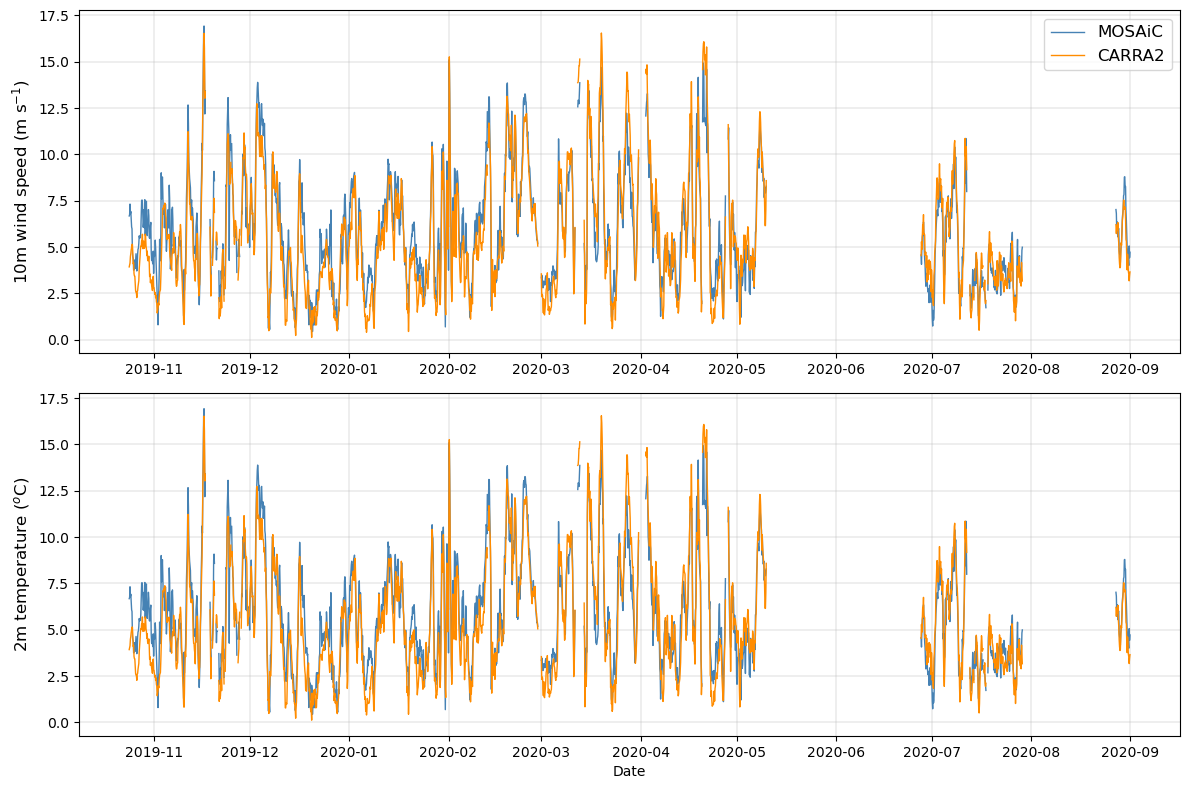

In [56]:
fig, ax = plt.subplots(2,1,figsize=(12, 8))
ax[0].plot(wspd_all_full['Datetime'],wspd_all_full['MOSAiC obs'], lw=1, color='steelblue',label='MOSAiC')
ax[0].plot(wspd_all_full['Date'],wspd_all_full['CARRA2'], lw=1, color='darkorange',label='CARRA2')
ax[0].set_ylabel('10m wind speed (m s$^{-1}$)',fontsize=12)

ax[1].plot(wspd_all_full['Date'],wspd_all_full['MOSAiC obs'], lw=1, color='steelblue')
ax[1].plot(wspd_all_full['Date'],wspd_all_full['CARRA2'], lw=1, color='darkorange')
ax[1].set_ylabel('2m temperature ($^{o}$C)',fontsize=12)

for i in range(0,2):
    ax[i].grid(linewidth = 0.3)

ax[1].set_xlabel('Date')
ax[0].legend(fontsize=12)
plt.tight_layout()
plt.show()